#### "Herramientas utilizadas"  ✔ ✖
-------
- **numpy ✔**
- **pandas ✔**
- **matplotlib o seaborn**  ✔ 
- **scikit-learn**
- **scipy**
- **nltk o spaCy**

### Ejecución 
 hacer : 
- **pip install spacy**
- **python -m spacy download en_core_web_sm**

### P 1 (Eleccion y descripcion del corpus)

El corpus utilizado en este proyecto corresponde a una colección de discursos inaugurales de presidentes de Estados Unidos, 
obtenida desde la plataforma Kaggle. Este conjunto de datos contiene un total de 58 documentos, que abarcan desde el primer presidente, 
George Washington (1789), hasta Donald Trump (2017).

Cada documento consiste en el texto completo de un discurso inaugural y está acompañado de metadatos, tales como el nombre del presidente
y la fecha del discurso. Estos textos presentan una extensión considerable y un lenguaje formal, lo que los hace adecuados para un análisis 
semántico.

https://www.kaggle.com/datasets/adhok93/presidentialaddress

### P 2 (Hipotesis inicial)

Se espera que los discursos presidenciales compartan una estructura semántica común centrada en conceptos como libertad, nación, gobierno y economía. Se anticipa que el análisis mediante SVD permitirá identificar estos temas latentes y agrupar discursos similares en el espacio reducido.


## P 3 (Preprocesamiento del texto)

Se realizó un preprocesamiento del corpus con el objetivo de mejorar la calidad semántica del análisis.

1. Normalización del texto:
Se convirtió todo el texto a minúsculas y se eliminaron números, signos de puntuación y caracteres no alfabéticos.

2. Eliminación de stopwords:
Se utilizaron las stopwords de ENGLISH_STOP_WORDS junto con un conjunto personalizado de palabras frecuentes pero poco informativas en discursos políticos.

3. Filtrado de términos:
Se aplicaron los parámetros min_df=2 y max_df=0.7 para eliminar palabras muy poco frecuentes y excesivamente frecuentes, reduciendo el ruido del corpus.

4. Vectorización:
Se utilizó TF-IDF para representar los documentos en una matriz término-documento ponderada por relevancia..

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
import spacy

# =========================
# 1. CARGA DE DATOS
# =========================

nlp = spacy.load("en_core_web_sm")

ruta = os.path.join("archive (3)", "inaug_speeches.csv")
df = pd.read_csv(ruta, encoding="latin1")

df["text"] = df["text"].fillna("")

In [71]:
# =========================
#2. PREPROCESAMIENTO 
# =========================

extra_stopwords = set([
    "shall", "let", "make", "know", "great", "new", "good",
    "people", "government", "nation", "america", "american",
    "states", "united", "country", "year", "time", "today"
])

stopwords_final = list(extra_stopwords.union(ENGLISH_STOP_WORDS))

def clean(text):
    doc = nlp(text.lower())

    tokens = [
        token.lemma_
        for token in doc
        if token.is_alpha
        and not token.is_stop
        and token.pos_ in ["NOUN", "VERB"]   # ✔ está bien
        and len(token.lemma_) > 2
    ]

    return " ".join(tokens)

df["text_clean"] = df["text"].apply(clean)



## P4 (Construcción de la matriz)

Se construyó la matriz término-documento utilizando TF-IDF. Esta representación permite ponderar palabras según su relevancia en cada documento.

Se utiliza la matriz CLEAN como base principal del análisis, ya que reduce el impacto de palabras demasiado frecuentes y mejora la separación semántica entre discursos.

In [73]:
# =========================
# 3. MATRIZ TF-IDF 
# =========================
vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=3,
    max_df=0.7,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df["text_clean"])
X = X.T


X = normalize(X, norm="l2", axis=1)

## P5 (Cálculo de la SVD)

Se aplicó la descomposición en valores singulares (SVD) a la matriz término-documento A:

A = U Σ Vᵀ

U representa relaciones entre términos
Vᵀ representa relaciones entre documentos
Σ contiene los valores singulares, que indican la importancia de cada dimensión

Los primeros valores singulares capturan la mayor parte de la información del corpus, mientras que los últimos representan ruido.

Esto permite reducir la dimensionalidad manteniendo la estructura semántica principal

In [74]:
U, s, VT = np.linalg.svd(X_clean, full_matrices=False)

## P6 (Valores singulares y elección de dimensión)

Se graficaron los valores singulares normalizados para analizar la distribución de información en las componentes.

Se observa un decaimiento fuerte en las primeras componentes, seguido de estabilización.

Esto indica que la mayor parte de la información se concentra en pocas dimensiones, por lo que se selecciona k = 2 o k = 3 como representación reducida.

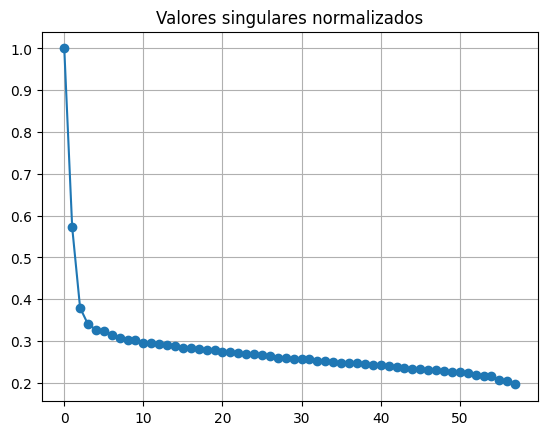

In [75]:
plt.plot(s / s[0], marker="o")
plt.title("Valores singulares normalizados")
plt.grid()
plt.show()

## P7 (Mapa semántico de documentos)

Se proyectaron los documentos en un espacio bidimensional utilizando las primeras componentes de la SVD.

Esto permite visualizar relaciones semánticas entre discursos, donde documentos cercanos comparten temáticas similares.

Se observan agrupaciones que reflejan similitudes en contenido político y temático.

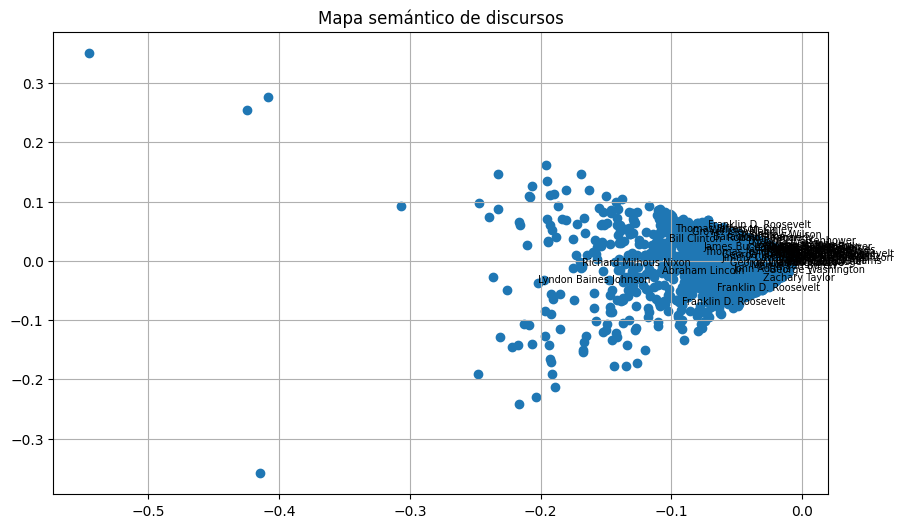

In [76]:
docs_2d = U[:, :2] * s[:2]

plt.figure(figsize=(10,6))
plt.scatter(docs_2d[:,0], docs_2d[:,1])

for i, name in enumerate(df["Name"]):
    plt.text(docs_2d[i,0], docs_2d[i,1], name, fontsize=7)

plt.title("Mapa semántico de discursos")
plt.grid()
plt.show()

## P8 (Exploración semántica)

Se analizan las palabras con mayor contribución en cada componente latente obtenido mediante SVD, con el objetivo de interpretar las direcciones semánticas principales del corpus.

Componente 1:
Las palabras más representativas se relacionan con procesos de acción, logro y cumplimiento de objetivos, tales como “accomplish”, “achievement” y “adherence”. Esto sugiere una dimensión asociada a la realización de acciones y metas dentro del discurso.

Componente 2:
Este componente agrupa términos asociados a estados de abundancia, aceptación y ausencia, como “abundance”, “acceptance” y “absence”. Esto indica una dimensión semántica vinculada a condiciones sociales o estados generales.

Componente 3:
Se observan palabras relacionadas con actividad, responsabilidad y acumulación, como “activity”, “accountability” y “accumulation”. Este componente parece capturar una dimensión asociada a la dinámica institucional y la gestión de acciones colectivas.

En conjunto, los componentes reflejan estructuras semánticas abstractas propias del lenguaje político, donde los conceptos aparecen agrupados en torno a nociones de acción, estado y responsabilidad.

In [78]:
vocab = vectorizer.get_feature_names_out()

for i in range(3):
    top = np.argsort(VT[i])[-10:]
    print(f"\nComponente {i+1}:")
    print([vocab[j] for j in top])


Componente 1:
['abandon', 'acquiescence', 'accomplish object', 'achievement', 'adherence', 'admit', 'abolish', 'action', 'accomplish', 'abandonment']

Componente 2:
['abuse', 'acceptance', 'absorb', 'abundance', 'accompany', 'absence', 'accept', 'accession', 'abound', 'accept obligation']

Componente 3:
['acquiesce', 'achieve', 'activity', 'accountability', 'act act', 'acquisition', 'acknowledge', 'accumulation', 'acquire', 'act']


## P9 (Conclusión)

El análisis mediante descomposición en valores singulares (SVD) permitió identificar estructuras semánticas latentes en el corpus de discursos presidenciales.

Se observa que el lenguaje utilizado presenta una alta concentración en conceptos abstractos relacionados con acción, administración y condiciones sociales generales. Esto es consistente con la naturaleza formal y política del corpus.

La reducción dimensional permitió representar el corpus en un espacio semántico reducido, facilitando la interpretación de patrones globales en los discursos. Sin embargo, los componentes obtenidos no representan “temas” en sentido estricto, sino direcciones matemáticas de máxima variabilidad semántica.

En conclusión, SVD resulta una herramienta útil para explorar relaciones semánticas en grandes volúmenes de texto, aunque su interpretación requiere análisis cuidadoso debido a la naturaleza abstracta de los componentes resultantes.